# Laptop Price Predictor — Part 3 of 4
### Data Visualization · Correlation · Features/target separation · Feature Selection · Feature Scaling · PCA · Encoding

| Part | Notebook | Assignment steps |
|---|---|---|
| 1 | `Part1_Data_Loading_and_Feature_Extraction.ipynb` | 1 Import Library · 2 Data Loading · 3 Feature Extraction · 4 Data Info |
| 2 | `Part2_Missing_Data_and_Duplicates.ipynb` | 5 Checking missing data · 6 Missing Data Treatment · 7 Duplicate Checking · 8 Duplicate Removing |
| **3** | **`Part3_Visualization_and_Feature_Engineering.ipynb`** ← you are here | **9 Data Visualization · 10 Correlation with target · 11 Features and target separation · 12 Feature Selection · 13 Feature Scaling · 14 PCA · 15 Encoding** |
| 4 | `Part4_Model_Training_and_Cross_Validation.ipynb` | 16 Train Test Split · 17 Model Preparation · 18 Model Accuracy · 19 Cross_val function · 20 cross_val Accuracy |

**Input:** `laptop_part2_clean.csv` (from Part 2) → **Output:** `laptop_part3_model_ready.csv`

**Running in Google Colab:** *Runtime → Run all*. Upload `laptop_part2_clean.csv` when asked.

## Setup: libraries and the Part 2 output

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import f_oneway
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    from google.colab import files  # this import only works inside Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


def find_file(name):
    """Find a data file next to the notebook, in a data/ folder or in Colab's /content.
    In Colab, if the file is missing, ask for an upload."""
    for folder in [".", "data", "/content", "/content/data"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    if IN_COLAB:
        print(f"'{name}' was not found - please upload it.")
        uploaded = files.upload()
        return next(iter(uploaded))  # Colab saves the upload in /content
    raise FileNotFoundError(f"Put '{name}' next to this notebook (or in a data/ folder) and run again.")


def save_output(frame, name):
    """Save a CSV for the next part. In Colab the file is also downloaded so you can upload it there."""
    folder = "data" if os.path.isdir("data") else "."
    path = os.path.join(folder, name)
    frame.to_csv(path, index=False)
    print(f"Saved {path}  ->  {frame.shape[0]} rows x {frame.shape[1]} columns")
    if IN_COLAB:
        files.download(path)

# One quiet chart style for the whole project: recessive grid, data in color, text in ink.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, BLUE_LIGHT, ORANGE, RED = "#2a78d6", "#b7d3f6", "#eb6834", "#e34948"
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3de", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.prop_cycle": plt.cycler(color=SERIES), "font.size": 10, "figure.dpi": 100,
    "lines.linewidth": 2,
})
thousands = mticker.StrMethodFormatter("{x:,.0f}")


df = pd.read_csv(find_file("laptop_part2_clean.csv"))
print("Shape:", df.shape)
df.head()

Shape: (832, 20)


,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
0,ASUS,celeron,Intel,5,4,DDR4,0,1024,Windows,64,0,Casual,1,No,No,23990.0,11,Intel Core i5,15.6,1024
1,ASUS,vivobook,Intel,5,4,DDR3,512,0,Windows,64,0,Casual,1,No,No,37990.0,10,Intel Core i5,15.6,512
2,HP,core,Intel,APU Dual,4,DDR3,512,0,Windows,64,0,ThinNlight,1,No,Yes,54990.0,11,Entry level,15.6,512
3,HP,core,Intel,APU Dual,4,DDR3,512,0,Windows,64,0,ThinNlight,0,No,No,54990.0,11,Entry level,15.6,512
4,LENOVO,ideapad,Intel,APU Dual,4,DDR3,0,1024,Windows,64,0,ThinNlight,1,No,Yes,35990.0,10,Entry level,15.6,1024


## Step 9: Data Visualization

### 9.1 How are prices distributed?

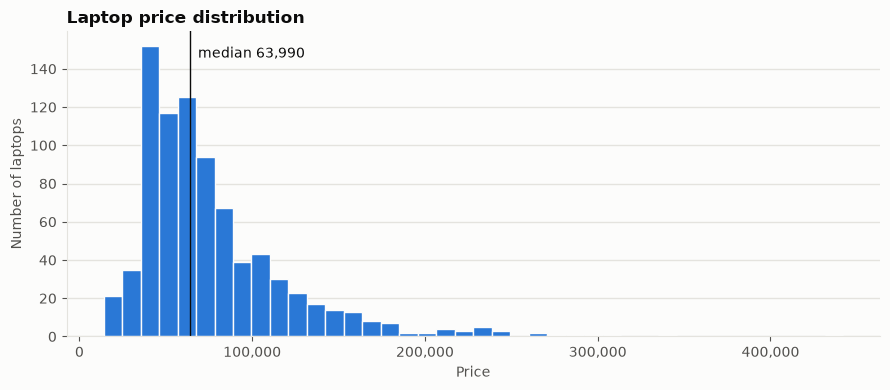

count       832.0
mean      77248.0
std       46875.0
min       13990.0
25%       46148.0
50%       63990.0
75%       91992.0
max      441990.0


Skewness: 2.35


In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["price"], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=1)
median_price = df["price"].median()
ax.axvline(median_price, color=INK, linewidth=1)
ax.text(median_price, ax.get_ylim()[1] * 0.95, f"  median {median_price:,.0f}", color=INK, va="top")
ax.set_title("Laptop price distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Number of laptops")
ax.xaxis.set_major_formatter(thousands)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(df["price"].describe().round(0).to_string())
print("Skewness:", round(df["price"].skew(), 2))

Prices are **right-skewed** (skewness 2.35): the middle half of the laptops cost between about 46,000 and
92,000, with a long tail of expensive models up to 441,990. The median (63,990) is a better "typical price"
than the mean (77,248).

### 9.2 Which brands are in the data, and how expensive are they?

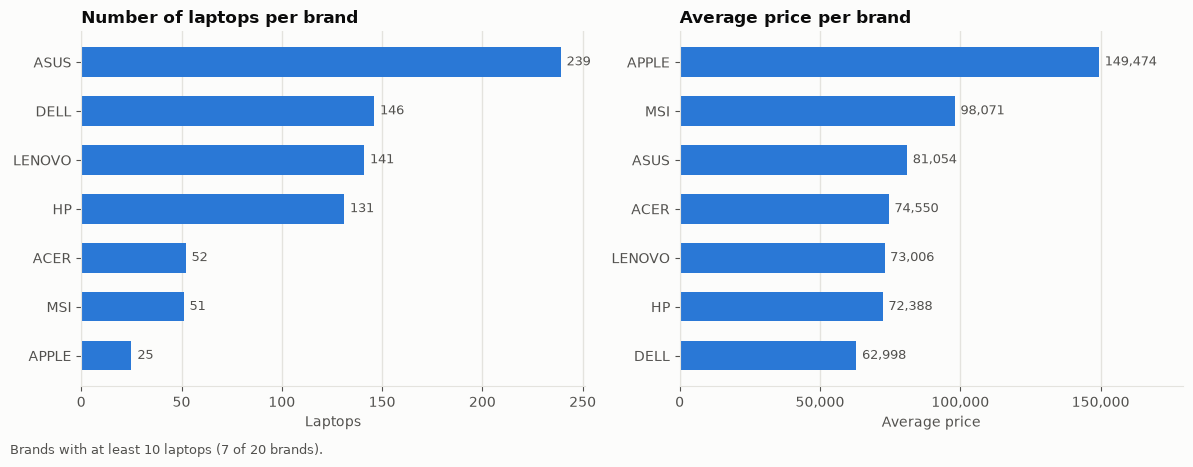

In [3]:
brand_stats = df.groupby("brand")["price"].agg(laptops="size", avg_price="mean").sort_values("laptops")
big_brands = brand_stats[brand_stats["laptops"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(big_brands.index, big_brands["laptops"], color=BLUE, height=0.6)
for y, n in enumerate(big_brands["laptops"]):
    axes[0].text(n + 3, y, str(n), va="center", color=INK_2, fontsize=9)
axes[0].set_title("Number of laptops per brand")
axes[0].set_xlabel("Laptops")

by_price = big_brands.sort_values("avg_price")
axes[1].barh(by_price.index, by_price["avg_price"], color=BLUE, height=0.6)
for y, p in enumerate(by_price["avg_price"]):
    axes[1].text(p + 2000, y, f"{p:,.0f}", va="center", color=INK_2, fontsize=9)
axes[1].set_title("Average price per brand")
axes[1].set_xlabel("Average price")
axes[1].xaxis.set_major_formatter(thousands)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(4))
axes[1].set_xlim(0, by_price["avg_price"].max() * 1.2)
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.text(0.01, -0.02, f"Brands with at least 10 laptops ({len(big_brands)} of {len(brand_stats)} brands).",
         color=INK_2, fontsize=9)
plt.tight_layout()
plt.show()

ASUS, DELL, LENOVO and HP make up most of the data. **APPLE** is by far the most expensive brand on average
(about 149,000), followed by **MSI** (gaming laptops, about 98,000). DELL is the cheapest of the big brands
(about 63,000). Brand clearly matters for price.

### 9.3 Price by CPU family

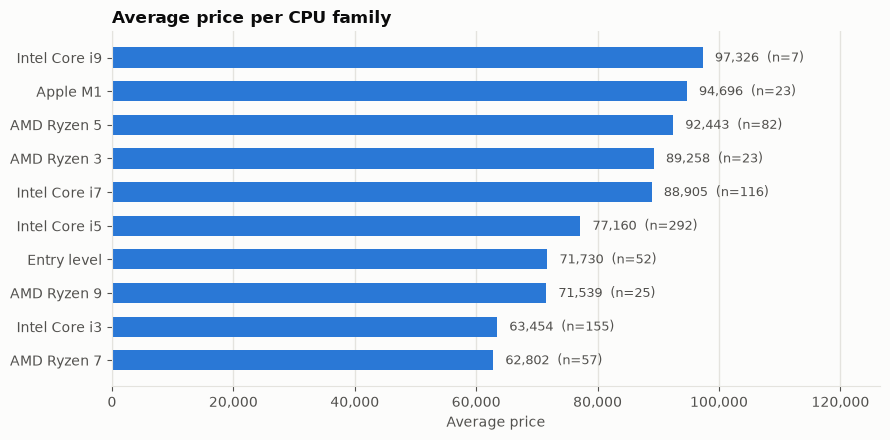

In [4]:
cpu_stats = df.groupby("cpu_family")["price"].agg(laptops="size", avg_price="mean").sort_values("avg_price")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(cpu_stats.index, cpu_stats["avg_price"], color=BLUE, height=0.6)
for y, (p, n) in enumerate(zip(cpu_stats["avg_price"], cpu_stats["laptops"])):
    ax.text(p + 2000, y, f"{p:,.0f}  (n={n})", va="center", color=INK_2, fontsize=9)
ax.set_title("Average price per CPU family")
ax.set_xlabel("Average price")
ax.xaxis.set_major_formatter(thousands)
ax.set_xlim(0, cpu_stats["avg_price"].max() * 1.3)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

A faster CPU family does not always mean a higher price here. The Core i9 and Apple M1 are at the top, but the
Ryzen 7 has the lowest average of all (62,802), just below the Core i3, while the Ryzen 3 averages 89,258.
In some rows of this scraped dataset, values landed in the wrong column, so a single feature can be noisy.
That is one reason the models in Part 4 reach moderate, not perfect, accuracy.

### 9.4 Price by RAM size and laptop type

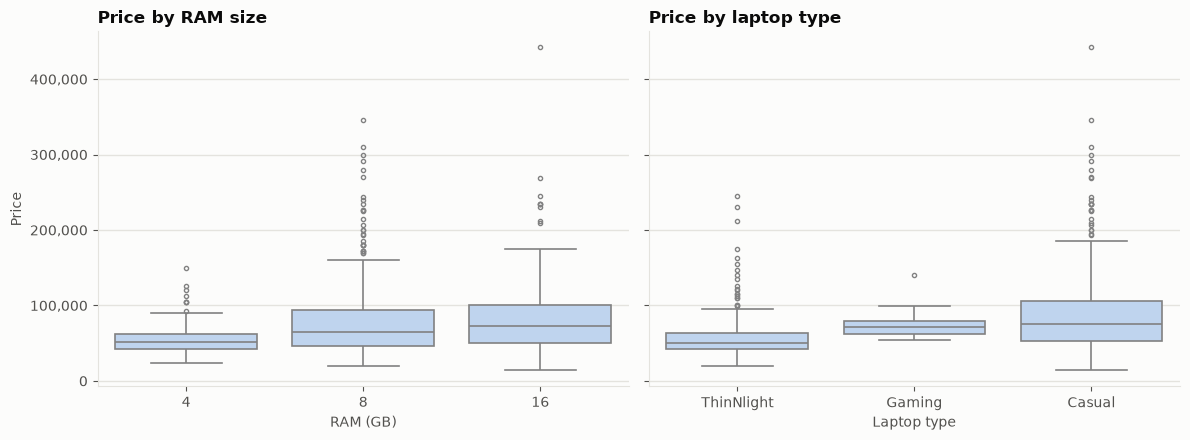

ram_gb
4     51990.0
8     64990.0
16    73400.0

laptop_type
Casual        74990.0
Gaming        71990.0
ThinNlight    49990.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
box_style = dict(color=BLUE_LIGHT, linewidth=1.2, fliersize=3)

sns.boxplot(data=df, x="ram_gb", y="price", ax=axes[0], **box_style)
axes[0].set_title("Price by RAM size")
axes[0].set_xlabel("RAM (GB)")

type_order = df.groupby("laptop_type")["price"].median().sort_values().index
sns.boxplot(data=df, x="laptop_type", y="price", order=type_order, ax=axes[1], **box_style)
axes[1].set_title("Price by laptop type")
axes[1].set_xlabel("Laptop type")

axes[0].set_ylabel("Price")
axes[0].yaxis.set_major_formatter(thousands)
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(df.groupby("ram_gb")["price"].median().rename("median price").to_string(), end="\n\n")
print(df.groupby("laptop_type")["price"].median().rename("median price").to_string())

- **RAM:** the median price rises from 51,990 (4 GB) to 64,990 (8 GB) and 73,400 (16 GB), but the boxes overlap a
  lot, so RAM alone does not decide the price.
- **Laptop type:** `ThinNlight` laptops are the cheapest (median 49,990). `Casual` laptops have the widest
  range and include the most expensive models; the few `Gaming` laptops sit in a narrow band around 72,000.

### 9.5 Price by SSD size and graphics card memory

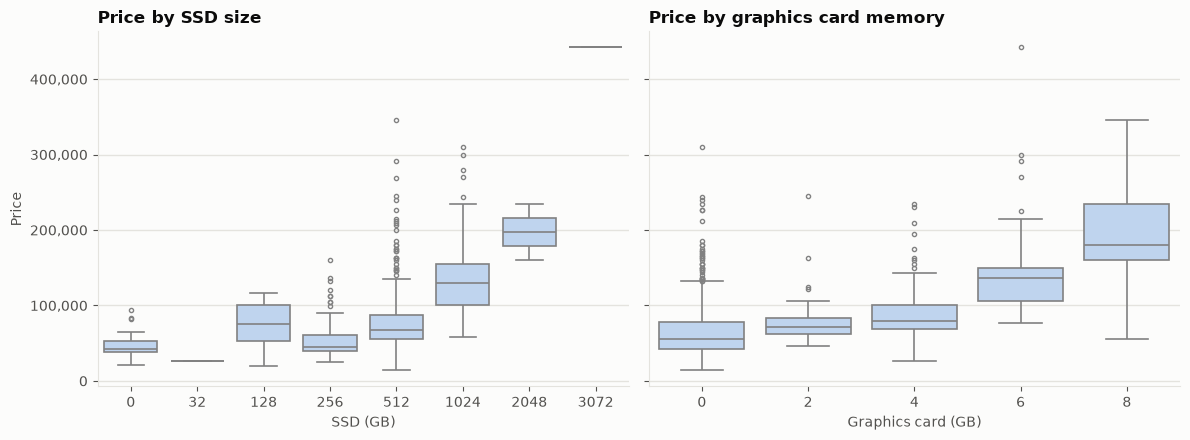

      size    median
ssd                 
0       67   42190.0
32       1   26899.0
128     10   75050.0
256    185   44490.0
512    459   68090.0
1024   107  129990.0
2048     2  196990.0
3072     1  441990.0

                 size    median
graphic_card_gb                
0                 578   54990.0
2                  64   70985.0
4                 133   79990.0
6                  40  136490.0
8                  17  179990.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.boxplot(data=df, x="ssd", y="price", ax=axes[0], **box_style)
axes[0].set_title("Price by SSD size")
axes[0].set_xlabel("SSD (GB)")

sns.boxplot(data=df, x="graphic_card_gb", y="price", ax=axes[1], **box_style)
axes[1].set_title("Price by graphics card memory")
axes[1].set_xlabel("Graphics card (GB)")

axes[0].set_ylabel("Price")
axes[0].yaxis.set_major_formatter(thousands)
for ax in axes:
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(df.groupby("ssd")["price"].agg(["size", "median"]).round(0).to_string(), end="\n\n")
print(df.groupby("graphic_card_gb")["price"].agg(["size", "median"]).round(0).to_string())

These two show the clearest pattern so far. The median price climbs with **SSD size** (68,090 at 512 GB →
129,990 at 1 TB → 196,990 at 2 TB) and with **graphics card memory** (54,990 with no dedicated card →
179,990 with 8 GB). Laptops with no SSD (HDD only) are among the cheapest.

## Step 10: Checking Correlation between target and other columns

Correlation (Pearson *r*) measures how strongly a numeric column moves with `price`:
+1 = rises together, −1 = one rises while the other falls, 0 = no straight-line relationship.

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.drop("price").tolist()
corr_with_price = df[numeric_cols].corrwith(df["price"]).sort_values()

corr_with_price.to_frame("correlation with price").round(3)

,correlation with price
hdd,-0.210
display_inch,-0.070
os_bit,-0.069
processor_gen,0.007
warranty,0.026
ram_gb,0.124
total_storage_gb,0.286
graphic_card_gb,0.484
ssd,0.608


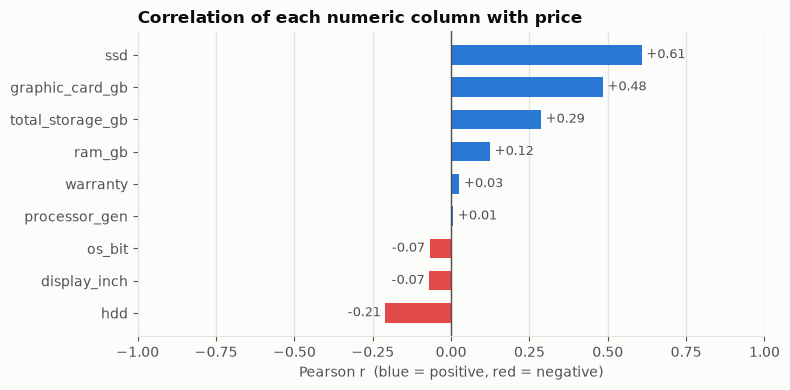

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [BLUE if r > 0 else RED for r in corr_with_price]
ax.barh(corr_with_price.index, corr_with_price, color=colors, height=0.6)
for y, r in enumerate(corr_with_price):
    ax.text(r + (0.015 if r >= 0 else -0.015), y, f"{r:+.2f}", va="center",
            ha="left" if r >= 0 else "right", color=INK_2, fontsize=9)
ax.axvline(0, color=INK_2, linewidth=1)
ax.set_title("Correlation of each numeric column with price")
ax.set_xlabel("Pearson r  (blue = positive, red = negative)")
ax.set_xlim(-1, 1)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

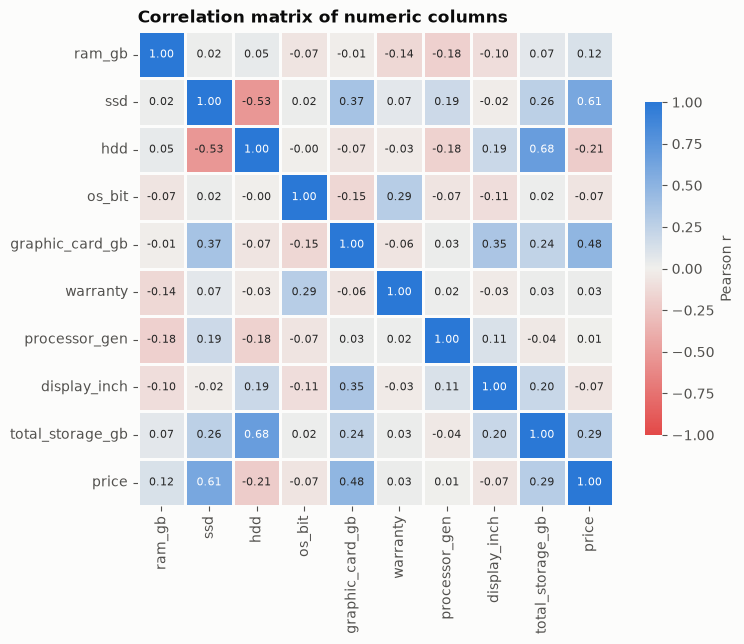

In [9]:
# Diverging colour scale: red (negative) - grey (zero) - blue (positive)
diverging = LinearSegmentedColormap.from_list("red_grey_blue", [RED, "#f0efec", BLUE])

corr_matrix = df[numeric_cols + ["price"]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_matrix, cmap=diverging, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=2, linecolor=SURFACE, square=True,
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation matrix of numeric columns")
plt.tight_layout()
plt.show()

- **`ssd` (+0.61)** and **`graphic_card_gb` (+0.48)** have the strongest link with price, as the box plots
  showed.
- **`hdd` is negative (−0.21)**: laptops that still use a hard disk are cheaper models.
- `processor_gen` (+0.01), `warranty` (+0.03), `os_bit` (−0.07) and `display_inch` (−0.07) are close to 0:
  almost no straight-line relationship with price.
- In the matrix, `total_storage_gb` moves closely with `hdd` (+0.68). It is built from `ssd` and `hdd`, so it
  repeats their information (Step 12 deals with this).
- Correlation only covers numeric columns. Text columns (brand, CPU family…) are tested in Step 12.4.

## Step 11: Features and target separation

- **Target (`y`)**: `price`, the value we want to predict.
- **Features (`X`)**: every other column.

In [10]:
X = df.drop(columns=["price"])
y = df["price"]

print("X (features):", X.shape)
print("y (target)  :", y.shape)
print("\nFeature columns:", X.columns.tolist())

X (features): (832, 19)
y (target)  : (832,)

Feature columns: ['brand', 'model', 'processor_brand', 'processor_name', 'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb', 'laptop_type', 'warranty', 'touchscreen', 'msoffice', 'processor_gen', 'cpu_family', 'display_inch', 'total_storage_gb']


## Step 12: Feature Selection

Four checks decide which features the model keeps.

### 12.1 Drop columns with too many categories or a cleaner replacement

In [11]:
print("model          unique values:", X["model"].nunique(), "for", len(X), "laptops")
print("processor_name unique values:", X["processor_name"].nunique(), "-> replaced by cpu_family with",
      X["cpu_family"].nunique(), "values")

X = X.drop(columns=["model", "processor_name"])
print("\nDropped: model, processor_name  ->  X:", X.shape)

model          unique values: 106 for 832 laptops
processor_name unique values: 33 -> replaced by cpu_family with 10 values

Dropped: model, processor_name  ->  X: (832, 17)


- `model` has about one unique name for every 8 laptops; one-hot encoding it would add a column per name, most
  of them with only 1–2 laptops, which the model would simply memorise.
- `processor_name` is replaced by the clean `cpu_family` built in Part 1.

### 12.2 Drop redundant features

In [12]:
print("total_storage_gb == ssd + hdd for every laptop:",
      bool((X["total_storage_gb"] == X["ssd"] + X["hdd"]).all()))

X = X.drop(columns=["total_storage_gb"])
print("Dropped: total_storage_gb  ->  X:", X.shape)

total_storage_gb == ssd + hdd for every laptop: True
Dropped: total_storage_gb  ->  X: (832, 16)


`total_storage_gb` is an exact sum of `ssd` and `hdd`, so it adds no new information, and in Linear Regression
it makes the coefficients unstable (perfect multicollinearity). It was still useful for exploring the data.

### 12.3 Numeric features: F-test with `SelectKBest`

`f_regression` tests each numeric feature against `price`. A **p-value below 0.05** means the relationship is
unlikely to be chance, so the feature is kept.

In [13]:
num_features = X.select_dtypes(include="number").columns.tolist()
selector = SelectKBest(score_func=f_regression, k="all").fit(X[num_features], y)

num_scores = pd.DataFrame({"F score": selector.scores_.round(2), "p-value": selector.pvalues_.round(4)},
                          index=num_features).sort_values("F score", ascending=False)
num_scores["keep"] = num_scores["p-value"] < 0.05
num_scores

,F score,p-value,keep
ssd,486.38,0.0000,True
graphic_card_gb,253.64,0.0000,True
hdd,38.16,0.0000,True
ram_gb,12.93,0.0003,True
display_inch,4.07,0.0440,True
os_bit,3.96,0.0470,True
warranty,0.56,0.4545,False
processor_gen,0.04,0.8473,False


### 12.4 Categorical features: one-way ANOVA

For a text column, ANOVA checks whether the average price differs between its groups
(for example between `Windows` and `Mac` laptops). Again, **p < 0.05 → keep**.

In [14]:
cat_features = X.select_dtypes(exclude="number").columns.tolist()
anova_rows = []
for col in cat_features:
    groups = [group["price"].to_numpy() for _, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    anova_rows.append((col, X[col].nunique(), round(f_stat, 2), round(p_value, 4)))

cat_scores = pd.DataFrame(anova_rows, columns=["feature", "groups", "F score", "p-value"]).set_index("feature")
cat_scores["keep"] = cat_scores["p-value"] < 0.05
cat_scores.sort_values("F score", ascending=False)

,groups,F score,p-value,keep
feature,,,,
os,2,65.98,0.0000,True
laptop_type,3,36.11,0.0000,True
touchscreen,2,26.73,0.0000,True
processor_brand,5,14.50,0.0000,True
msoffice,2,11.22,0.0008,True
brand,20,10.49,0.0000,True
cpu_family,10,4.83,0.0000,True
ram_type,7,1.98,0.0657,False


### 12.5 Selected features

In [15]:
dropped_by_test = num_scores.index[~num_scores["keep"]].tolist() + cat_scores.index[~cat_scores["keep"]].tolist()
X = X.drop(columns=dropped_by_test)

num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

print("Dropped by the statistical tests:", dropped_by_test)
print(f"\nSelected numeric features    ({len(num_features)}):", num_features)
print(f"Selected categorical features ({len(cat_features)}):", cat_features)
print("\nX:", X.shape)

Dropped by the statistical tests: ['warranty', 'processor_gen', 'ram_type']

Selected numeric features    (6): ['ram_gb', 'ssd', 'hdd', 'os_bit', 'graphic_card_gb', 'display_inch']
Selected categorical features (7): ['brand', 'processor_brand', 'os', 'laptop_type', 'touchscreen', 'msoffice', 'cpu_family']

X: (832, 13)


**Result: 13 of the 19 features are kept.**

| Dropped | Reason |
|---|---|
| `model`, `processor_name` | Too many categories / replaced by `cpu_family` |
| `total_storage_gb` | Exact copy of `ssd + hdd` |
| `warranty`, `processor_gen` | F-test p-value above 0.05: no significant link with price |
| `ram_type` | ANOVA p-value 0.066, above 0.05 |

`display_inch` and `os_bit` only just pass (p ≈ 0.04–0.05); they are kept because they meet the rule.

## Step 13: Feature Scaling

The numeric features have very different ranges (RAM 4–16, SSD 0–3072). **StandardScaler** rescales each one to
mean 0 and standard deviation 1, so no feature dominates just because its numbers are bigger. This matters for
PCA (next step) and for distance- or coefficient-based models.

In [16]:
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X[num_features]), columns=num_features, index=X.index)

comparison = pd.DataFrame({
    "mean before": X[num_features].mean(), "std before": X[num_features].std(),
    "mean after": X_num_scaled.mean(), "std after": X_num_scaled.std(ddof=0),
}).round(3)
comparison

,mean before,std before,mean after,std after
ram_gb,9.755,4.071,0.0,1.0
ssd,481.269,290.086,0.0,1.0
hdd,172.308,382.490,-0.0,1.0
os_bit,59.269,11.365,0.0,1.0
graphic_card_gb,1.245,2.088,0.0,1.0
display_inch,14.784,0.947,-0.0,1.0


In [17]:
X_num_scaled.head()

,ram_gb,ssd,hdd,os_bit,graphic_card_gb,display_inch
0,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412
1,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412
2,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412
3,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412
4,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412


## Step 14: PCA (Principal Component Analysis)

PCA combines the scaled numeric features into new, uncorrelated components ordered by how much of the variation
(information) they keep. If a few components keep most of it, they can replace the original features.

In [18]:
pca = PCA()
X_pca = pca.fit_transform(X_num_scaled)

explained = pd.DataFrame({
    "component": [f"PC{i + 1}" for i in range(pca.n_components_)],
    "explained variance %": (pca.explained_variance_ratio_ * 100).round(1),
    "cumulative %": (np.cumsum(pca.explained_variance_ratio_) * 100).round(1),
}).set_index("component")
explained

,explained variance %,cumulative %
component,,
PC1,28.1,28.1
PC2,23.8,51.9
PC3,17.8,69.7
PC4,14.8,84.5
PC5,9.3,93.8
PC6,6.2,100.0


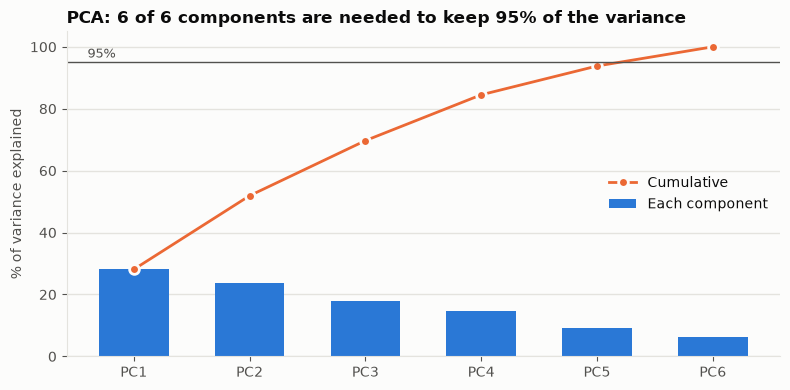

In [19]:
n_95 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, pca.n_components_ + 1)
ax.bar(x, explained["explained variance %"], color=BLUE, width=0.6, label="Each component")
ax.plot(x, explained["cumulative %"], color=ORANGE, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, label="Cumulative")
ax.axhline(95, color=INK_2, linewidth=1)
ax.text(x[0] - 0.4, 96.5, "95%", color=INK_2, fontsize=9)
ax.set_xticks(x, explained.index)
ax.set_ylim(0, 105)
ax.set_ylabel("% of variance explained")
ax.set_title(f"PCA: {n_95} of {pca.n_components_} components are needed to keep 95% of the variance")
ax.legend(frameon=False, loc="center right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

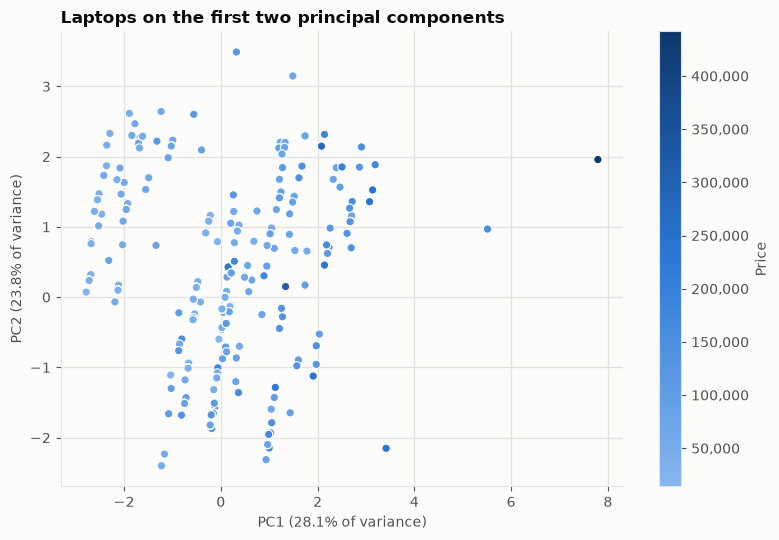

,PC1,PC2
ram_gb,-0.03,-0.08
ssd,0.67,-0.16
hdd,-0.54,0.41
os_bit,-0.09,-0.33
graphic_card_gb,0.49,0.47
display_inch,0.10,0.68


In [20]:
fig, ax = plt.subplots(figsize=(8, 5.5))
price_ramp = LinearSegmentedColormap.from_list("blue_ramp", ["#86b6ef", BLUE, "#0d366b"])  # light -> dark blue
points = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=price_ramp, s=36, edgecolors=SURFACE, linewidths=0.8)
cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Price")
cbar.formatter = thousands
cbar.update_ticks()
ax.set_title("Laptops on the first two principal components")
ax.set_xlabel(f"PC1 ({explained.iloc[0, 0]}% of variance)")
ax.set_ylabel(f"PC2 ({explained.iloc[1, 0]}% of variance)")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_[:2].T, index=num_features, columns=["PC1", "PC2"]).round(2)
loadings

- The 6 numeric features are only weakly correlated with each other, so the information is spread out: PC1 keeps
  28.1%, 5 components reach 93.8%, and all 6 are needed for 95%. PCA cannot shrink these features without
  losing information.
- PC1 is mostly `ssd` (+0.67) and `graphic_card_gb` (+0.49) against `hdd` (−0.54): a high PC1 means a laptop
  with a big SSD and a graphics card. In the scatter plot, the expensive (dark) laptops sit on the right, so PC1
  is linked to price.
- Part 4 tests PCA as a model step (**PCA + Linear Regression**) to see whether it helps accuracy.

## Step 15: Encoding

Models need numbers, so text columns are converted:

1. **Binary encoding:** `Yes` / `No` columns → 1 / 0.
2. **Rare brands:** brands with fewer than 10 laptops are grouped as `OTHER`, so they do not each get a nearly
   empty column.
3. **One-hot encoding** (`pd.get_dummies`): every other text column becomes one 0/1 column per category.
   `drop_first=True` drops one category per column (it is implied when all the others are 0).

In [21]:
X_enc = X.copy()

# 15.1 Binary encoding
binary_cols = [c for c in cat_features if set(X_enc[c].unique()) <= {"Yes", "No"}]
for col in binary_cols:
    X_enc[col] = X_enc[col].map({"Yes": 1, "No": 0})
print("Binary encoded (Yes=1, No=0):", binary_cols)

# 15.2 Group rare brands
brand_counts = X_enc["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index.tolist()
X_enc["brand"] = X_enc["brand"].where(~X_enc["brand"].isin(rare_brands), "OTHER")
print(f"\nRare brands grouped as OTHER ({len(rare_brands)}):", rare_brands)
print("Brands now:", sorted(X_enc["brand"].unique()))

Binary encoded (Yes=1, No=0): ['touchscreen', 'msoffice']

Rare brands grouped as OTHER (13): ['AVITA', 'LG', 'VAIO', 'REALME', 'NOKIA', 'INFINIX', 'ALIENWARE', 'REDMIBOOK', 'MICROSOFT', 'MI', 'SMARTRON', 'SAMSUNG', 'IBALL']
Brands now: ['ACER', 'APPLE', 'ASUS', 'DELL', 'HP', 'LENOVO', 'MSI', 'OTHER']


In [22]:
# 15.3 One-hot encoding
onehot_cols = [c for c in cat_features if c not in binary_cols]
X_enc = pd.get_dummies(X_enc, columns=onehot_cols, drop_first=True, dtype=int)

print("One-hot encoded:", onehot_cols)
print("Shape before encoding:", X.shape, " ->  after:", X_enc.shape)
X_enc.head()

One-hot encoded: ['brand', 'processor_brand', 'os', 'laptop_type', 'cpu_family']
Shape before encoding: (832, 13)  ->  after: (832, 31)


,ram_gb,ssd,hdd,os_bit,graphic_card_gb,touchscreen,msoffice,display_inch,brand_APPLE,brand_ASUS,brand_DELL,brand_HP,brand_LENOVO,brand_MSI,brand_OTHER,processor_brand_Apple,processor_brand_Intel,processor_brand_MediaTek,processor_brand_Qualcomm,os_Windows,laptop_type_Gaming,laptop_type_ThinNlight,cpu_family_AMD Ryzen 5,cpu_family_AMD Ryzen 7,cpu_family_AMD Ryzen 9,cpu_family_Apple M1,cpu_family_Entry level,cpu_family_Intel Core i3,cpu_family_Intel Core i5,cpu_family_Intel Core i7,cpu_family_Intel Core i9
0,4,0,1024,64,0,0,0,15.6,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,4,512,0,64,0,0,0,15.6,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,4,512,0,64,0,0,1,15.6,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,4,512,0,64,0,0,0,15.6,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,4,0,1024,64,0,0,1,15.6,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0


In [23]:
print("Every column is numeric now:", X_enc.select_dtypes(exclude="number").empty)
print("\nNew columns:")
for col in onehot_cols:
    print(f"  {col:<16} ->", [c for c in X_enc.columns if c.startswith(col + "_") and c not in X.columns])

Every column is numeric now: True

New columns:
  brand            -> ['brand_APPLE', 'brand_ASUS', 'brand_DELL', 'brand_HP', 'brand_LENOVO', 'brand_MSI', 'brand_OTHER']
  processor_brand  -> ['processor_brand_Apple', 'processor_brand_Intel', 'processor_brand_MediaTek', 'processor_brand_Qualcomm']
  os               -> ['os_Windows']
  laptop_type      -> ['laptop_type_Gaming', 'laptop_type_ThinNlight']
  cpu_family       -> ['cpu_family_AMD Ryzen 5', 'cpu_family_AMD Ryzen 7', 'cpu_family_AMD Ryzen 9', 'cpu_family_Apple M1', 'cpu_family_Entry level', 'cpu_family_Intel Core i3', 'cpu_family_Intel Core i5', 'cpu_family_Intel Core i7', 'cpu_family_Intel Core i9']


### The final feature matrix

Putting the steps together: scaled numeric features (Step 13) + encoded categorical features (Step 15). This is
what a model sees.

In [24]:
X_final = pd.concat([X_num_scaled, X_enc.drop(columns=num_features)], axis=1)
print("Final feature matrix:", X_final.shape)
X_final.head()

Final feature matrix: (832, 31)


,ram_gb,ssd,hdd,os_bit,graphic_card_gb,display_inch,touchscreen,msoffice,brand_APPLE,brand_ASUS,brand_DELL,brand_HP,brand_LENOVO,brand_MSI,brand_OTHER,processor_brand_Apple,processor_brand_Intel,processor_brand_MediaTek,processor_brand_Qualcomm,os_Windows,laptop_type_Gaming,laptop_type_ThinNlight,cpu_family_AMD Ryzen 5,cpu_family_AMD Ryzen 7,cpu_family_AMD Ryzen 9,cpu_family_Apple M1,cpu_family_Entry level,cpu_family_Intel Core i3,cpu_family_Intel Core i5,cpu_family_Intel Core i7,cpu_family_Intel Core i9
0,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
2,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,-1.414369,0.106000,-0.450760,0.416514,-0.596795,0.861412,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,-1.414369,-1.660054,2.228042,0.416514,-0.596795,0.861412,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0


### Save for Part 4

The saved file has the **selected and encoded** features (not yet scaled) plus `price`.

Why not save the scaled data? Scaling and PCA *learn* from the data (means, standard deviations, components). In
Part 4 they are fitted on the **training set only**, inside a pipeline, so the test set stays unseen. Fitting them
here on all rows would let information from the test laptops leak into training (*data leakage*).

In [25]:
model_ready = X_enc.copy()
model_ready["price"] = y
save_output(model_ready, "laptop_part3_model_ready.csv")

Saved data/laptop_part3_model_ready.csv  ->  832 rows x 32 columns


**Next:** open `Part4_Model_Training_and_Cross_Validation.ipynb`.